In [1]:
# basic imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# reproducibility
np.random.seed(0)

In [2]:
# load diabetes dataset
data = pd.read_csv("diabetes.csv")

# preview data
print(data.head())
print("\nShape:", data.shape)

   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  

Shape: (768, 9)


In [3]:
# assuming last column is Outcome
X = data.iloc[:, :-1].values
y = data.iloc[:, -1].values.reshape(-1, 1)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (768, 8)
y shape: (768, 1)


In [4]:
# simple feature scaling
X = (X - X.mean(axis=0)) / X.std(axis=0)

print("Feature scaling done.")

Feature scaling done.


In [5]:
# split 80-20
split = int(0.8 * len(X))

X_train = X[:split]
y_train = y[:split]

X_test = X[split:]
y_test = y[split:]

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 614
Testing samples: 154


In [6]:
# sigmoid activation
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

# derivative
def sigmoid_derivative(z):
    s = sigmoid(z)
    return s * (1 - s)

In [7]:
input_size = X_train.shape[1]   # 8
hidden_size = 10
output_size = 1

# weight initialization
W1 = np.random.randn(input_size, hidden_size)
b1 = np.zeros((1, hidden_size))

W2 = np.random.randn(hidden_size, output_size)
b2 = np.zeros((1, output_size))

learning_rate = 0.01
epochs = 1000

In [8]:
losses = []

for epoch in range(epochs):
    
    # Forward pass
    z1 = np.dot(X_train, W1) + b1
    a1 = sigmoid(z1)
    
    z2 = np.dot(a1, W2) + b2
    y_pred = sigmoid(z2)
    
    # MSE loss
    loss = np.mean((y_train - y_pred)**2)
    losses.append(loss)
    
    # Backpropagation
    
    # output layer
    d_loss_output = 2 * (y_pred - y_train) / y_train.shape[0]
    d_output = d_loss_output * sigmoid_derivative(z2)
    
    dW2 = np.dot(a1.T, d_output)
    db2 = np.sum(d_output, axis=0, keepdims=True)
    
    # hidden layer
    d_hidden = np.dot(d_output, W2.T)
    d_hidden = d_hidden * sigmoid_derivative(z1)
    
    dW1 = np.dot(X_train.T, d_hidden)
    db1 = np.sum(d_hidden, axis=0, keepdims=True)
    
    # update
    W2 -= learning_rate * dW2
    b2 -= learning_rate * db2
    
    W1 -= learning_rate * dW1
    b1 -= learning_rate * db1
    
    if epoch % 200 == 0:
        print(f"Epoch {epoch}, Loss: {loss:.4f}")

Epoch 0, Loss: 0.3965
Epoch 200, Loss: 0.2951
Epoch 400, Loss: 0.2432
Epoch 600, Loss: 0.2201
Epoch 800, Loss: 0.2086


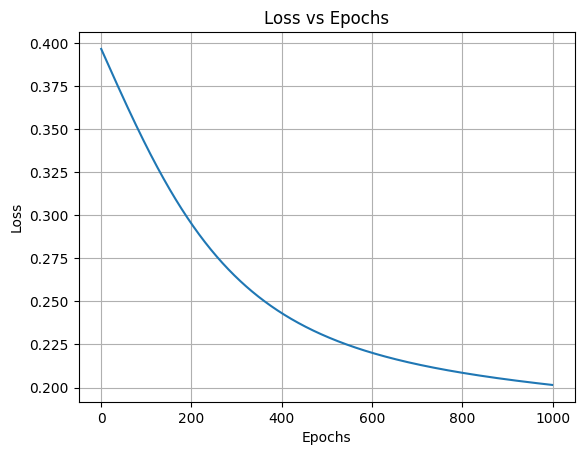

In [9]:
plt.plot(losses)
plt.title("Loss vs Epochs")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

In [10]:
# forward pass on test data
z1_test = np.dot(X_test, W1) + b1
a1_test = sigmoid(z1_test)

z2_test = np.dot(a1_test, W2) + b2
y_test_pred = sigmoid(z2_test)

# convert to 0 or 1
predictions = (y_test_pred >= 0.5).astype(int)

accuracy = np.mean(predictions == y_test)

print("Test Accuracy:", accuracy)

Test Accuracy: 0.6688311688311688
